## Map Reduce

```
START
  ↓
ORCHESTRATOR (splits PDF into chunks)
  ↓ ↓ ↓ ↓ ↓ (parallel)
MAP 0   MAP 1   MAP 2 ... MAP N
  ↓ ↓ ↓ ↓ ↓
REDUCE (merge summaries)
  ↓
END
```


In [3]:

# langgraph_mapreduce_wordcount.py
from typing import TypedDict, List, Dict, Annotated
from operator import add
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send, Command
from langgraph.checkpoint.memory import InMemorySaver

In [4]:
# ---- State types ----
class AggregateState(TypedDict, total=False):
    docs: List[str]
    # Annotate partials with a reducer (list concatenation)
    partials: Annotated[List[Dict[str,int]], add]
    final_counts: Dict[str,int]

class WorkerState(TypedDict):
    doc: str

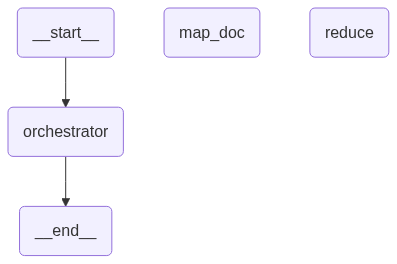

In [5]:

# ---- Orchestrator: fan-out map jobs ----
def orchestrator(state: AggregateState) -> Command:
    docs = state.get("docs", []) or []
    sends = [Send("map_doc", {"doc": d}) for d in docs]
    # return a Command that dispatches multiple Sends
    return Command(update={}, goto=sends)

# ---- Map node: count words in a single document ----
def map_doc(state: WorkerState) -> Dict[str, List[Dict[str,int]]]:
    text = state.get("doc", "")
    counts: Dict[str,int] = {}
    for token in text.split():
        w = token.lower().strip(".,!?:;\"'()[]")
        if not w:
            continue
        counts[w] = counts.get(w, 0) + 1
    # return as a one-element list under 'partials' so reducer concatenates lists
    return {"partials": [counts]}

# ---- Reduce node: combine all partial counts ----
def reducer(state: AggregateState) -> Dict[str, Dict[str,int]]:
    final: Dict[str,int] = {}
    for part in state.get("partials", []):
        for word, cnt in part.items():
            final[word] = final.get(word, 0) + cnt
    return {"final_counts": final}

# ---- Build graph ----
def build_mapreduce_graph() -> StateGraph:
    builder = StateGraph(AggregateState)

    builder.add_node("orchestrator", orchestrator)
    builder.add_node("map_doc", map_doc)
    builder.add_node("reduce", reducer)

    builder.add_edge(START, "orchestrator")
    # map_doc results feed into reduce
    builder.add_edge("map_doc", "reduce")
    builder.add_edge("reduce", END)

    graph = builder.compile(checkpointer=InMemorySaver())
    return graph

graph= build_mapreduce_graph()

graph



## “LangGraph graph diagrams do not show dynamic fan-out edges created using Send.
## These edges exist only at runtime.”

```
START
  ↓
orchestrator
  ↓↓↓↓↓↓↓
map_doc map_doc map_doc   (parallel)
      ↓   ↓   ↓
        reduce
           ↓
          END


```

In [8]:
# ---- Run example ----
if __name__ == "__main__":
    # docs = [
    #     "Hello world hello",
    #     "World of code and Hello",
    #     "Another document. Code world!"
    # ]
    
    docs= [
        "Peak Performance Gym was founded in 2015 by former Olympic athlete Marcus Chen. With over 15 years of experience in professional athletics, Marcus established the gym to provide personalized fitness solutions for people of all levels. The gym spans 10,000 square feet and features state-of-the-art equipment.",
        "Peak Performance Gym is open Monday through Friday from 5:00 AM to 11:00 PM. On weekends, our hours are 7:00 AM to 9:00 PM. We remain closed on major national holidays. Members with Premium access can enter using their key cards 24/7, including holidays.",
        "Our membership plans include: Basic (₹1,500/month) with access to gym floor and basic equipment; Standard (₹2,500/month) adds group classes and locker facilities; Premium (₹4,000/month) includes 24/7 access, personal training sessions, and spa facilities. We offer student and senior citizen discounts of 15% on all plans. Corporate partnerships are available for companies with 10+ employees joining."
    ]
    initial_state: AggregateState = {
        "docs": docs,
        "partials": [],
        "final_counts": {}
    }

    graph = build_mapreduce_graph()
    config = {"configurable": {"thread_id": "mapreduce_example_1"}}

    # invoke the graph (runs the orchestrator -> map -> reduce)
    graph.invoke(initial_state, config=config)

    # get the final StateSnapshot
    snapshot = graph.get_state(config)

    print("Final StateSnapshot:", snapshot.values)

    # IMPORTANT: snapshot is a StateSnapshot object — values are in snapshot.values
    final_counts = snapshot.values.get("final_counts", {})

    print("Final word counts:", final_counts)


Final StateSnapshot: {'docs': ['Peak Performance Gym was founded in 2015 by former Olympic athlete Marcus Chen. With over 15 years of experience in professional athletics, Marcus established the gym to provide personalized fitness solutions for people of all levels. The gym spans 10,000 square feet and features state-of-the-art equipment.', 'Peak Performance Gym is open Monday through Friday from 5:00 AM to 11:00 PM. On weekends, our hours are 7:00 AM to 9:00 PM. We remain closed on major national holidays. Members with Premium access can enter using their key cards 24/7, including holidays.', 'Our membership plans include: Basic (₹1,500/month) with access to gym floor and basic equipment; Standard (₹2,500/month) adds group classes and locker facilities; Premium (₹4,000/month) includes 24/7 access, personal training sessions, and spa facilities. We offer student and senior citizen discounts of 15% on all plans. Corporate partnerships are available for companies with 10+ employees joini

## From the PDF 

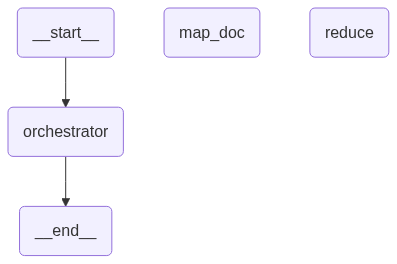

In [9]:
# mapreduce_pdf_wordcount.py
import os
from typing import TypedDict, List, Dict, Annotated
from operator import add

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send, Command
from langgraph.checkpoint.memory import InMemorySaver

# PDF extraction
from pdfminer.high_level import extract_text

# -----------------------------
# 1. Load PDFs & split into chunks
# -----------------------------

def load_pdfs_as_chunks(folder: str, chunk_size: int = 1500) -> List[str]:
    pdf_files = [f for f in os.listdir(folder) if f.lower().endswith(".pdf")]
    all_chunks = []

    for pdf in pdf_files:
        path = os.path.join(folder, pdf)
        print(f"Reading PDF: {path}")

        raw_text = extract_text(path)
        raw_text = raw_text.replace("\n", " ")

        # Split into chunks
        chunks = []
        words = raw_text.split()
        current = []

        for w in words:
            current.append(w)
            if len(current) >= chunk_size:
                chunks.append(" ".join(current))
                current = []

        if current:
            chunks.append(" ".join(current))

        print(f" -> extracted {len(chunks)} chunks from {pdf}")
        all_chunks.extend(chunks)

    return all_chunks

# -----------------------------
# 2. Map-Reduce State Definitions
# -----------------------------

class AggregateState(TypedDict, total=False):
    docs: List[str]
    partials: Annotated[List[Dict[str,int]], add]
    final_counts: Dict[str,int]

class WorkerState(TypedDict):
    doc: str

# -----------------------------
# 3. Map-Reduce Nodes
# -----------------------------

def orchestrator(state: AggregateState) -> Command:
    docs = state.get("docs", [])
    sends = [Send("map_doc", {"doc": d}) for d in docs]
    return Command(update={}, goto=sends)

def map_doc(state: WorkerState) -> Dict[str, List[Dict[str,int]]]:
    text = state.get("doc", "")
    counts: Dict[str,int] = {}

    for token in text.split():
        w = token.lower().strip(".,!?:;\"'()[]")
        if not w:
            continue
        counts[w] = counts.get(w, 0) + 1

    return {"partials": [counts]}  # reducer will merge lists

def reducer(state: AggregateState) -> Dict[str, Dict[str,int]]:
    final: Dict[str,int] = {}
    for part in state.get("partials", []):
        for w, c in part.items():
            final[w] = final.get(w, 0) + c
    return {"final_counts": final}

# -----------------------------
# 4. Build Graph
# -----------------------------

def build_mapreduce_graph() -> StateGraph:
    builder = StateGraph(AggregateState)

    builder.add_node("orchestrator", orchestrator)
    builder.add_node("map_doc", map_doc)
    builder.add_node("reduce", reducer)

    builder.add_edge(START, "orchestrator")
    builder.add_edge("map_doc", "reduce")
    builder.add_edge("reduce", END)

    return builder.compile(checkpointer=InMemorySaver())

graph= build_mapreduce_graph()
graph

In [10]:
# -----------------------------
# 5. Execution
# -----------------------------

if __name__ == "__main__":
    folder = r"/Users/sachinmishra/Desktop/Agents_From_Scratch/financial_pdfs"

    print("📄 Loading PDFs...")
    docs = load_pdfs_as_chunks(folder, chunk_size=1000)

    print(f"Total chunks for Map-Reduce: {len(docs)}")

    initial_state: AggregateState = {
        "docs": docs,
        "partials": [],
        "final_counts": {}
    }

    graph = build_mapreduce_graph()
    config = {"configurable": {"thread_id": "pdf_mr_wordcount"}}

    graph.invoke(initial_state, config=config)

    snapshot = graph.get_state(config)
    final_counts = snapshot.values.get("final_counts", {})

    print("\n======================")
    print("📊 FINAL WORD COUNTS:")
    print("======================\n")

    # print top 30 words
    sorted_words = sorted(final_counts.items(), key=lambda x: x[1], reverse=True)
    for w, c in sorted_words[:30]:
        print(f"{w:<20} {c}")


The PDF <_io.BufferedReader name='/Users/sachinmishra/Desktop/Agents_From_Scratch/financial_pdfs/DB_Annual_2023.pdf'> contains a metadata field indicating that it should not allow text extraction. Ignoring this field and proceeding. Use the check_extractable if you want to raise an error in this case


📄 Loading PDFs...
Reading PDF: /Users/sachinmishra/Desktop/Agents_From_Scratch/financial_pdfs/DB_Annual_2023.pdf
 -> extracted 381 chunks from DB_Annual_2023.pdf
Reading PDF: /Users/sachinmishra/Desktop/Agents_From_Scratch/financial_pdfs/JPM_Annual_2023.pdf
 -> extracted 208 chunks from JPM_Annual_2023.pdf
Reading PDF: /Users/sachinmishra/Desktop/Agents_From_Scratch/financial_pdfs/JPM_SE_Annual_2023.pdf
 -> extracted 128 chunks from JPM_SE_Annual_2023.pdf
Total chunks for Map-Reduce: 717

📊 FINAL WORD COUNTS:

the                  40207
of                   22492
and                  22237
to                   16210
in                   14393
–                    11504
a                    8370
for                  7299
or                   6215
as                   5895
0                    5832
on                   5651
is                   5065
by                   4350
are                  4336
risk                 4304
bank                 4128
with                 3848
2023      

## Without Map Reduce:

In [11]:
# sequential_pdf_wordcount.py
import os
import time
from typing import Dict, List
from pdfminer.high_level import extract_text

# --------------------------------------------------------
# 1. Load PDFs and split into chunks
# --------------------------------------------------------

def load_pdfs_as_chunks(folder: str, chunk_size: int = 1500) -> List[str]:
    pdf_files = [f for f in os.listdir(folder) if f.lower().endswith(".pdf")]
    all_chunks = []

    for pdf in pdf_files:
        path = os.path.join(folder, pdf)
        print(f"Reading PDF: {path}")

        raw_text = extract_text(path)
        raw_text = raw_text.replace("\n", " ")

        # Split into chunks
        chunks = []
        words = raw_text.split()
        current = []

        for w in words:
            current.append(w)
            if len(current) >= chunk_size:
                chunks.append(" ".join(current))
                current = []

        if current:
            chunks.append(" ".join(current))

        print(f" -> extracted {len(chunks)} chunks from {pdf}")
        all_chunks.extend(chunks)

    return all_chunks

# --------------------------------------------------------
# 2. Sequential word counting (NO MAP-REDUCE)
# --------------------------------------------------------

def word_count_sequential(chunks: List[str]) -> Dict[str, int]:
    final_counts: Dict[str, int] = {}

    print(f"\nProcessing {len(chunks)} chunks sequentially...")

    for idx, text in enumerate(chunks):
        if idx % 10 == 0:
            print(f"Processing chunk {idx}/{len(chunks)}")

        words = text.split()
        for token in words:
            w = token.lower().strip(".,!?:;\"'()[]")
            if not w:
                continue
            final_counts[w] = final_counts.get(w, 0) + 1

    return final_counts

# --------------------------------------------------------
# 3. Run sequential process and measure time
# --------------------------------------------------------

if __name__ == "__main__":
    folder = r"/Users/sachinmishra/Desktop/LangGraph_Project_Based_Learning/financial_pdfs"

    print("📄 Loading PDFs...")
    chunks = load_pdfs_as_chunks(folder, chunk_size=1000)

    print(f"Total chunks for sequential processing: {len(chunks)}")

    start = time.time()
    final_counts = word_count_sequential(chunks)
    end = time.time()

    print("\n======================")
    print("📊 FINAL WORD COUNTS (Sequential)")
    print("======================\n")

    sorted_words = sorted(final_counts.items(), key=lambda x: x[1], reverse=True)

    for w, c in sorted_words[:30]:
        print(f"{w:<20} {c}")

    print("\n⏱️ TOTAL TIME (Sequential):", round(end - start, 2), "seconds")


📄 Loading PDFs...
Reading PDF: /Users/sachinmishra/Desktop/LangGraph_Project_Based_Learning/financial_pdfs/JPM_Annual_2023.pdf
 -> extracted 208 chunks from JPM_Annual_2023.pdf
Reading PDF: /Users/sachinmishra/Desktop/LangGraph_Project_Based_Learning/financial_pdfs/JPM_SE_Annual_2023.pdf
 -> extracted 128 chunks from JPM_SE_Annual_2023.pdf
Total chunks for sequential processing: 336

Processing 336 chunks sequentially...
Processing chunk 0/336
Processing chunk 10/336
Processing chunk 20/336
Processing chunk 30/336
Processing chunk 40/336
Processing chunk 50/336
Processing chunk 60/336
Processing chunk 70/336
Processing chunk 80/336
Processing chunk 90/336
Processing chunk 100/336
Processing chunk 110/336
Processing chunk 120/336
Processing chunk 130/336
Processing chunk 140/336
Processing chunk 150/336
Processing chunk 160/336
Processing chunk 170/336
Processing chunk 180/336
Processing chunk 190/336
Processing chunk 200/336
Processing chunk 210/336
Processing chunk 220/336
Processing 

## map reduce with timing:

In [26]:
import os
import time
from typing import TypedDict, List, Dict, Annotated
from operator import add

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send, Command
from langgraph.checkpoint.memory import InMemorySaver

from pdfminer.high_level import extract_text

# ============================
# 1. Read PDFs → chunks
# ============================

def load_pdfs_as_chunks(folder: str, chunk_size: int = 1500) -> List[str]:
    pdf_files = [f for f in os.listdir(folder) if f.lower().endswith(".pdf")]
    all_chunks = []

    for pdf in pdf_files:
        path = os.path.join(folder, pdf)
        print(f"Reading PDF: {path}")

        raw_text = extract_text(path).replace("\n", " ")

        words = raw_text.split()
        chunks = []
        current = []

        for w in words:
            current.append(w)
            if len(current) >= chunk_size:
                chunks.append(" ".join(current))
                current = []

        if current:
            chunks.append(" ".join(current))

        print(f" -> Extracted {len(chunks)} chunks from {pdf}")
        all_chunks.extend(chunks)

    return all_chunks


# ============================
# 2. Map-Reduce State
# ============================

class AggregateState(TypedDict, total=False):
    docs: List[str]
    partials: Annotated[List[Dict[str,int]], add]
    final_counts: Dict[str,int]

    # timing fields
    map_start: float
    map_end: float
    reduce_start: float
    reduce_end: float


class WorkerState(TypedDict):
    doc: str


# ============================
# 3. Nodes
# ============================

def orchestrator(state: AggregateState) -> Command:
    """Fan-out map tasks"""
    docs = state.get("docs", [])
    sends = [Send("map_doc", {"doc": d}) for d in docs]

    # start MAP phase timer
    return Command(
        update={"map_start": time.time()},
        goto=sends
    )


def map_doc(state: WorkerState) -> Dict[str, List[Dict[str,int]]]:
    """Map: count words in one chunk"""
    text = state.get("doc", "")
    counts: Dict[str,int] = {}

    for token in text.split():
        w = token.lower().strip(".,!?:;\"'()[]")
        if not w:
            continue
        counts[w] = counts.get(w, 0) + 1

    return {"partials": [counts]}


def reducer(state: AggregateState) -> Dict[str, Dict[str,int]]:
    """Reduce: combine all word counts"""
    final: Dict[str,int] = {}

    # end MAP phase when entering reducer
    reduce_start = time.time()
    update_time = {"reduce_start": reduce_start}

    for part in state.get("partials", []):
        for w, c in part.items():
            final[w] = final.get(w, 0) + c

    # mark REDUCE end
    update_time["reduce_end"] = time.time()

    # also mark MAP end only once (safe)
    if "map_end" not in state:
        update_time["map_end"] = reduce_start

    return {**update_time, "final_counts": final}


# ============================
# 4. Build graph
# ============================

def build_mapreduce_graph() -> StateGraph:
    builder = StateGraph(AggregateState)

    builder.add_node("orchestrator", orchestrator)
    builder.add_node("map_doc", map_doc)
    builder.add_node("reduce", reducer)

    builder.add_edge(START, "orchestrator")
    builder.add_edge("map_doc", "reduce")
    builder.add_edge("reduce", END)

    return builder.compile(checkpointer=InMemorySaver())


# ============================
# 5. Main execution
# ============================

if __name__ == "__main__":
    folder = r"/Users/sachinmishra/Desktop/LangGraph_Project_Based_Learning/financial_pdfs"

    print("📄 Loading PDFs...")
    docs = load_pdfs_as_chunks(folder, chunk_size=1000)
    print(f"Total chunks: {len(docs)}")

    initial_state: AggregateState = {
        "docs": docs,
        "partials": [],
        "final_counts": {}
    }

    graph = build_mapreduce_graph()
    config = {"configurable": {"thread_id": "pdf_mr_timed"}}

    total_start = time.time()
    graph.invoke(initial_state, config=config)
    total_end = time.time()

    snapshot = graph.get_state(config)
    values = snapshot.values

    # Timings
    map_time = values["map_end"] - values["map_start"]
    reduce_time = values["reduce_end"] - values["reduce_start"]
    total_time = total_end - total_start

    print("\n===============================")
    print("⏱️ MAP-REDUCE TIMING RESULTS")
    print("===============================\n")
    print(f"MAP phase time:      {map_time:.4f} seconds")
    print(f"REDUCE phase time:   {reduce_time:.4f} seconds")
    print(f"TOTAL time:          {total_time:.4f} seconds\n")

    print("Top 30 words:\n")
    final_counts = values["final_counts"]
    for w, c in sorted(final_counts.items(), key=lambda x: x[1], reverse=True)[:30]:
        print(f"{w:<20} {c}")


📄 Loading PDFs...
Reading PDF: /Users/sachinmishra/Desktop/LangGraph_Project_Based_Learning/financial_pdfs/NIPS-2017-attention-is-all-you-need-Paper.pdf
 -> Extracted 6 chunks from NIPS-2017-attention-is-all-you-need-Paper.pdf
Total chunks: 6

⏱️ MAP-REDUCE TIMING RESULTS

MAP phase time:      0.0075 seconds
REDUCE phase time:   0.0001 seconds
TOTAL time:          0.0115 seconds

Top 30 words:

the                  279
and                  155
of                   152
in                   110
to                   102
a                    74
we                   66
attention            55
is                   43
model                42
for                  42
on                   35
with                 34
models               33
sequence             30
as                   30
our                  29
this                 29
output               27
=                    27
·                    27
neural               24
layer                24
self-attention       23
translation          

## Notes: 

## Another example

In [13]:
import os
import time
from pdfminer.high_level import extract_text
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv(override=True)

# ------------------------------
# LLM Setup
# ------------------------------
llm = ChatOpenAI(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    base_url="https://api.groq.com/openai/v1",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0.2
)

# ------------------------------
# PDF → chunks
# ------------------------------
def load_pdf_chunks(folder: str, chunk_size: int = 1500):
    files = [f for f in os.listdir(folder) if f.endswith(".pdf")]
    all_chunks = []

    for f in files:
        print(f"Reading PDF: {f}")
        text = extract_text(os.path.join(folder, f)).replace("\n", " ")
        words = text.split()
        
        chunk, chunks = [], []
        for w in words:
            chunk.append(w)
            if len(chunk) >= chunk_size:
                chunks.append(" ".join(chunk))
                chunk = []
        if chunk:
            chunks.append(" ".join(chunk))

        print(f" → Extracted {len(chunks)} chunks")
        all_chunks.extend(chunks)

    return all_chunks[:5]  # limit for testing


# ------------------------------
# Sequential summarization
# ------------------------------
def summarize_chunk(text: str):
    prompt = f"Summarize this text:\n{text}"
    return llm.invoke(prompt).content.strip()


def sequential_summarizer(chunks):
    chunk_summaries = []
    timings = []

    print("\n--- Sequential LLM Summaries ---\n")

    t0 = time.time()

    for i, chunk in enumerate(chunks):
        print(f"Summarizing chunk {i+1}/{len(chunks)} ...")
        start = time.time()
        summary = summarize_chunk(chunk)
        end = time.time()

        chunk_summaries.append(summary)
        timings.append(end - start)

        print(f" → Chunk time: {round(end-start, 2)} sec")

    t1 = time.time()

    # Final merge summary
    merge_start = time.time()
    final_summary = llm.invoke(
        f"Combine these summaries into one:\n\n{chunk_summaries}"
    ).content.strip()
    merge_end = time.time()

    print("\n==============================")
    print("SEQUENTIAL SUMMARY TIMINGS")
    print("==============================")
    print(f"Total chunks: {len(chunks)}")
    print(f"Chunk summarization time: {round(t1 - t0, 2)} sec")
    print(f"Final merge summary time: {round(merge_end - merge_start, 2)} sec")
    print(f"TOTAL Sequential Time:   {round(merge_end - t0, 2)} sec")

    return final_summary


# ------------------------------
# RUN
# ------------------------------
if __name__ == "__main__":
    folder = r"/Users/sachinmishra/Desktop/LangGraph_Project_Based_Learning/financial_pdfs"
    chunks = load_pdf_chunks(folder)

    print(f"\nTotal Chunks: {len(chunks)}\n")

    final = sequential_summarizer(chunks)

    print("\nFINAL SUMMARY:\n", final)


Reading PDF: JPM_Annual_2023.pdf
 → Extracted 139 chunks
Reading PDF: JPM_SE_Annual_2023.pdf
 → Extracted 86 chunks

Total Chunks: 5


--- Sequential LLM Summaries ---

Summarizing chunk 1/5 ...
 → Chunk time: 2.17 sec
Summarizing chunk 2/5 ...
 → Chunk time: 1.26 sec
Summarizing chunk 3/5 ...
 → Chunk time: 1.36 sec
Summarizing chunk 4/5 ...
 → Chunk time: 1.12 sec
Summarizing chunk 5/5 ...
 → Chunk time: 0.98 sec

SEQUENTIAL SUMMARY TIMINGS
Total chunks: 5
Chunk summarization time: 6.89 sec
Final merge summary time: 2.03 sec
TOTAL Sequential Time:   8.91 sec

FINAL SUMMARY:
 Here is a comprehensive summary combining the key points from the provided texts:

**JPMorgan Chase's 2023 Performance**

* **Record Revenue:** $162.4 billion (managed revenue) for the sixth consecutive year
* **Net Income:** $49.6 billion
* **Return on Tangible Common Equity (ROTCE):** 21%
* **Financial Highlights:**
	+ Total Net Revenue: $158,104 million (2023), $128,695 million (2022), $121,649 million (2021)


In [15]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv(override=True)

model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)

result = model.invoke('What is the capital of India')

print(result.content[0]["text"])

The capital of India is **New Delhi**.


In [16]:
import os
import time
from typing import List, Dict, TypedDict, Annotated
from operator import add
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send, Command
from langgraph.checkpoint.memory import InMemorySaver
from pdfminer.high_level import extract_text
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv(override=True)


# ------------------------------
# LLM Setup
# ------------------------------
# llm = ChatOpenAI(
#     model="openai/gpt-oss-20b",
#     base_url="https://api.groq.com/openai/v1",
#     api_key=os.getenv("GROQ_API_KEY"),
#     temperature=0.2
# )



llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)


# ------------------------------
# PDF → chunks
# ------------------------------
def load_pdf_chunks(folder: str, chunk_size: int = 1500):
    files = [f for f in os.listdir(folder) if f.endswith(".pdf")]
    all_chunks = []

    for f in files:
        print(f"Reading PDF: {f}")
        text = extract_text(os.path.join(folder, f)).replace("\n", " ")
        words = text.split()

        chunk, chunks = [], []
        for w in words:
            chunk.append(w)
            if len(chunk) >= chunk_size:
                chunks.append(" ".join(chunk))
                chunk = []
        if chunk:
            chunks.append(" ".join(chunk))

        print(f" → Extracted {len(chunks)} chunks")
        all_chunks.extend(chunks)

    return all_chunks[:5] # limit for testing


# ------------------------------
# MAP-REDUCE STATE
# ------------------------------
class MRState(TypedDict, total=False):
    docs: List[str]
    partials: Annotated[List[str], add]      # partial summaries
    final_summary: str

    # timers
    map_start: float
    map_end: float
    reduce_start: float
    reduce_end: float


class WorkerState(TypedDict):
    doc: str


# ------------------------------
# Nodes
# ------------------------------
def orchestrator(state: MRState) -> Command:
    docs = state["docs"]
    sends = [Send("map_node", {"doc": d}) for d in docs]

    return Command(
        update={"map_start": time.time()},
        goto=sends
    )


def map_node(state: WorkerState) -> Dict:
    """LLM summarize each chunk"""
    text = state["doc"]
    summary = llm.invoke(f"Summarize:\n{text}")
    summary= summary.content[0]["text"]
    return {"partials": [summary]}


def reduce_node(state: MRState) -> Dict:
    reduce_start = time.time()

    merged = llm.invoke(
        f"Combine these summaries into one:\n\n{state['partials']}"
    )
    merged= merged.content[0]["text"]

    reduce_end = time.time()

    return {
        "final_summary": merged,
        "map_end": state.get("map_end", reduce_start),
        "reduce_start": reduce_start,
        "reduce_end": reduce_end
    }


# ------------------------------
# BUILD GRAPH
# ------------------------------
def build_graph():
    builder = StateGraph(MRState)

    builder.add_node("orchestrator", orchestrator)
    builder.add_node("map_node", map_node)
    builder.add_node("reduce_node", reduce_node)

    builder.add_edge(START, "orchestrator")
    builder.add_edge("map_node", "reduce_node")
    builder.add_edge("reduce_node", END)

    return builder.compile(checkpointer=InMemorySaver())


# ------------------------------
# RUN
# ------------------------------
if __name__ == "__main__":
    folder = r"/Users/sachinmishra/Desktop/LangGraph_Project_Based_Learning/financial_pdfs"

    chunks = load_pdf_chunks(folder)
    print(f"\nTotal chunks: {len(chunks)}")

    graph = build_graph()
    config = {"configurable": {"thread_id": "mr_summarizer"}}

    total_start = time.time()
    graph.invoke({"docs": chunks, "partials": []}, config=config)
    total_end = time.time()

    snapshot = graph.get_state(config)
    v = snapshot.values

    print("\n==============================")
    print("MAP-REDUCE SUMMARY TIMINGS")
    print("==============================")
    print(f"MAP time:      {round(v['reduce_start'] - v['map_start'], 2)} sec")
    print(f"REDUCE time:   {round(v['reduce_end'] - v['reduce_start'], 2)} sec")
    print(f"TOTAL time:    {round(total_end - total_start, 2)} sec")
    print("==============================\n")

    print("FINAL SUMMARY:\n", v["final_summary"])


Reading PDF: JPM_Annual_2023.pdf
 → Extracted 139 chunks
Reading PDF: JPM_SE_Annual_2023.pdf
 → Extracted 86 chunks

Total chunks: 5

MAP-REDUCE SUMMARY TIMINGS
MAP time:      4.26 sec
REDUCE time:   3.13 sec
TOTAL time:    7.4 sec

FINAL SUMMARY:
 This comprehensive summary synthesizes the 2023 performance, strategic philosophy, and historical evolution of JPMorgan Chase & Co. as detailed in its annual reporting.

### **Financial Performance and Market Dominance**
2023 was a record-breaking year for JPMorgan Chase, characterized by significant growth and superior operational efficiency.
*   **Key Metrics:** The firm reported $158.1 billion in net revenue and $49.6 billion in net income. It achieved a 21% Return on Tangible Common Equity (ROTCE), significantly outperforming its peer group.
*   **Market Leadership:** The bank holds the #1 position in retail deposit market share, U.S. small business banking, global investment banking fees, and global private banking. It serves 82 million